In [1]:
import pandas as pd

data = pd.read_csv(r"C:\Users\EBIN BABU\Downloads\customer_chats_500_business_quality.csv")

print(data.head())

   chat_id                                            message  \
0        1          The product arrived damaged and unusable.   
1        2            I have a question regarding my account.   
2        3  My order has been delayed for over a week and ...   
3        4              The product quality is disappointing.   
4        5  My order has been delayed for over a week and ...   

  expected_sentiment  
0           Negative  
1            Neutral  
2           Negative  
3           Negative  
4           Negative  


In [2]:
#Text Preprocessing
import re

stop_words = {
    "a","an","the","and","or","but","if","to","of","in","on",
    "for","with","is","are","was","were","be","been","being",
    "this","that","these","those","it","its","at","by","from"
}

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

data["clean_message"] = data["message"].apply(clean_text)

In [3]:
import sys

print(sys.executable)

C:\Users\EBIN BABU\.conda\envs\dl_gpu\python.exe


In [4]:
import sys

!"{sys.executable}" -m pip install textblob

In [5]:
#Sentiment Analysis
from textblob import TextBlob

def get_sentiment(text):

    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

data["sentiment"] = data["message"].apply(get_sentiment)

In [6]:
#Hugging face
from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis"
)

result = classifier(
    "Delivery is delayed"
)

C:\Users\EBIN BABU\.conda\envs\dl_gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
C:\Users\EBIN BABU\.conda\envs\dl_gpu\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\EBIN BABU\.cache\huggingface\hub\models--distilbert--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISAB

In [12]:
# Common Complaints
complaints = [
    "delay",
    "refund",
    "payment",
    "missing",
    "damaged",
    "late"
]
def detect_complaint(text):

    for c in complaints:

        if c in text.lower():

            return c

    return "Other"

data["complaint_type"] = data["message"].apply(detect_complaint)

In [15]:
#Topic Categorization
def classify_topic(text):

    text = text.lower()

    if "delivery" in text:
        return "Delivery"

    elif "refund" in text:
        return "Refund"

    elif "payment" in text:
        return "Payment"

    elif "product" in text:
        return "Product"

    else:
        return "General"

data["topic"] = data["message"].apply(classify_topic)

In [19]:
#Generate Summary Report
import os

positive = len(data[data["sentiment"]=="Positive"])
negative = len(data[data["sentiment"]=="Negative"])
neutral = len(data[data["sentiment"]=="Neutral"])

report = f"""
CUSTOMER CHAT ANALYSIS REPORT

Total Chats : {len(data)}

Positive Chats : {positive}

Negative Chats : {negative}

Neutral Chats : {neutral}

Most Common Complaint :
{data['complaint_type'].value_counts().idxmax()}

Most Common Topic :
{data['topic'].value_counts().idxmax()}
"""

print(report)

# Create folder if it doesn't exist
os.makedirs("outputs", exist_ok=True)

# Save report
with open("outputs/report.txt", "w", encoding="utf-8") as f:
    f.write(report)

print("Report saved to outputs/report.txt")


CUSTOMER CHAT ANALYSIS REPORT

Total Chats : 500

Positive Chats : 117

Negative Chats : 83

Neutral Chats : 300

Most Common Complaint :
Other

Most Common Topic :
General

Report saved to outputs/report.txt


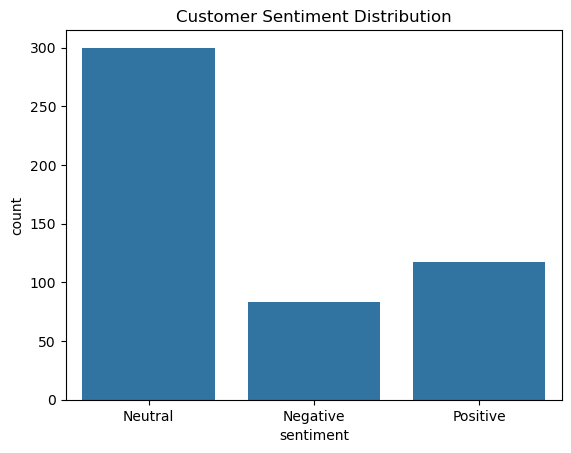

In [23]:
#visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(
    x="sentiment",
    data=data
)

plt.title(
    "Customer Sentiment Distribution"
)

plt.savefig(
    "outputs/sentiment_chart.png"
)

plt.show()

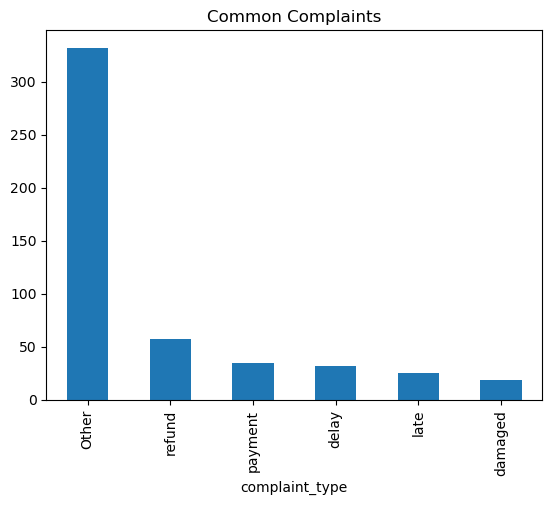

In [25]:
#complaint analysis
data["complaint_type"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Common Complaints"
)

plt.savefig(
    "outputs/complaint_chart.png"
)

plt.show()

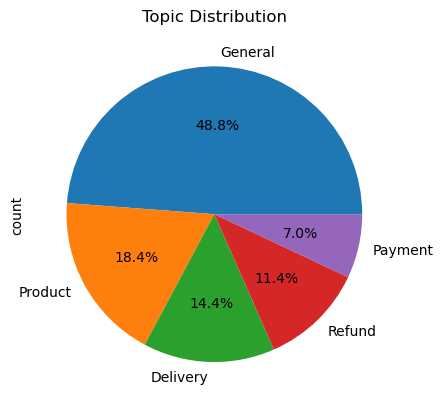

In [26]:
#topic Distribution
data["topic"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title(
    "Topic Distribution"
)

plt.savefig(
    "outputs/topic_chart.png"
)

plt.show()